In [1]:
import pandas as pd
df = pd.read_csv('/data/shared/fsibilla/wfp-da4hd/DATA/in/yem/Obs_YEMCln_20260212.csv')

In [2]:
df.head()

,ObsID,RspID,ObsDate,BirthYear,DM_HHAge,HHSize_90days,ADM1_NAME,ADM1_CODE,ADM2_NAME,ADM2_CODE,FCS,rCSI,HHExpF_MNCRD_7D,HHExpF_GiftAid_7D,HHExpF_Own_7D,HHExpNF_MNCRD_1M,HHExpNF_GiftAid_1M
0,6688817,CTC120625A2823,2025-08-01 00:00:00.000,28,28.0,8,Ibb,3419,Far' Al Odayn,32887.0,21.0,7.0,25000.0,0.0,0.0,4000.0,0.0
1,6686152,CTC150824A4683,2025-08-01 00:00:00.000,35,35.0,7,Ibb,3419,Ar Radmah,32879.0,33.0,14.0,21000.0,0.0,20000.0,8000.0,0.0
2,6687988,CTC010825A75,2025-08-01 00:00:00.000,50,50.0,12,Sana'a,3423,Khawlan,32950.0,56.0,21.0,30000.0,6000.0,0.0,0.0,6500.0
3,6689386,CTC170325A5664,2025-08-01 00:00:00.000,65,65.0,7,Ibb,3419,Ash Sha'ir,32884.0,28.0,12.0,8000.0,0.0,0.0,12000.0,0.0
4,6689572,CTC121224A2846,2025-08-01 00:00:00.000,35,35.0,9,Ibb,3419,Ash Sha'ir,32884.0,18.5,16.0,5000.0,0.0,5000.0,60000.0,0.0


In [3]:
df['ObsDate'] = pd.to_datetime(df['ObsDate'])

start = df['ObsDate'].min()
end = df['ObsDate'].max()

print("Start:", start)
print("End:", end)
print("Span:", end - start)

Start: 2025-08-01 00:00:00
End: 2026-01-31 00:00:00
Span: 183 days 00:00:00


In [4]:
df['RspID'].nunique()

44675

In [5]:
import numpy as np

In [6]:
df['log_exp_pp']=np.log((df['HHExpF_MNCRD_7D']+df['HHExpF_GiftAid_7D']+df['HHExpF_Own_7D']+df['HHExpNF_MNCRD_1M']+df['HHExpNF_GiftAid_1M'])/df['HHSize_90days'])

/data/shared/fsibilla/wfp-downscaling/.mamba/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [7]:
df['FES_eqiv']=(df['HHExpF_MNCRD_7D']+df['HHExpF_GiftAid_7D']+df['HHExpF_Own_7D'])/(df['HHExpNF_MNCRD_1M']+df['HHExpNF_GiftAid_1M'])

In [8]:
df.head()

,ObsID,RspID,ObsDate,BirthYear,DM_HHAge,HHSize_90days,ADM1_NAME,ADM1_CODE,ADM2_NAME,ADM2_CODE,FCS,rCSI,HHExpF_MNCRD_7D,HHExpF_GiftAid_7D,HHExpF_Own_7D,HHExpNF_MNCRD_1M,HHExpNF_GiftAid_1M,log_exp_pp,FES_eqiv
0,6688817,CTC120625A2823,2025-08-01,28,28.0,8,Ibb,3419,Far' Al Odayn,32887.0,21.0,7.0,25000.0,0.0,0.0,4000.0,0.0,8.195610,6.250000
1,6686152,CTC150824A4683,2025-08-01,35,35.0,7,Ibb,3419,Ar Radmah,32879.0,33.0,14.0,21000.0,0.0,20000.0,8000.0,0.0,8.853665,5.125000
2,6687988,CTC010825A75,2025-08-01,50,50.0,12,Sana'a,3423,Khawlan,32950.0,56.0,21.0,30000.0,6000.0,0.0,0.0,6500.0,8.172353,5.538462
3,6689386,CTC170325A5664,2025-08-01,65,65.0,7,Ibb,3419,Ash Sha'ir,32884.0,28.0,12.0,8000.0,0.0,0.0,12000.0,0.0,7.957577,0.666667
4,6689572,CTC121224A2846,2025-08-01,35,35.0,9,Ibb,3419,Ash Sha'ir,32884.0,18.5,16.0,5000.0,0.0,5000.0,60000.0,0.0,8.959026,0.166667


## attach mics wscore and entropy market access

In [9]:
adm1_wscore = pd.read_csv('/data/shared/fsibilla/wfp-da4hd/DATA/in/yem/adm1_mics_wscore.csv')

In [10]:
adm1_wscore['HH7'].nunique()

22

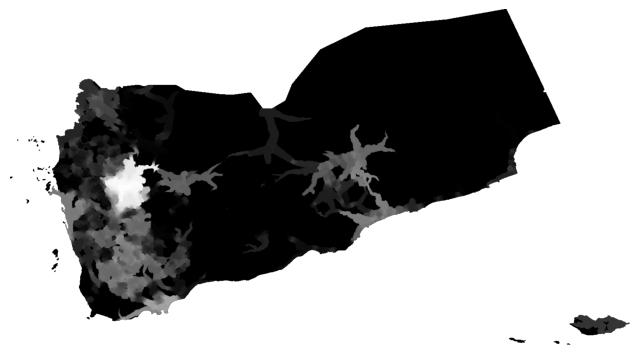

In [11]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

im = Image.open('/data/shared/fsibilla/wfp-da4hd/DATA/in/yem/entropy_mod_4h_moto.tif')

arr = np.array(im)

plt.figure(figsize=(8, 8))
plt.imshow(arr, cmap="gray")   # remove cmap=... if it's RGB
plt.axis("off")
plt.show()

In [12]:
import pandas as pd
import numpy as np
import re
import unicodedata

import geopandas as gpd
import rasterio
from rasterio.features import geometry_mask

tif_path = "/data/shared/fsibilla/wfp-da4hd/DATA/in/yem/entropy_mod_4h_moto.tif"
adm2_geojson = "/data/shared/fsibilla/wfp-da4hd/DATA/in/yem/geoBoundaries-YEM-ADM2_simplified.geojson"

In [13]:
def norm_name(s):
    if pd.isna(s):
        return ""
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(ch for ch in s if not unicodedata.combining(ch))
    s = s.replace("’", "'").replace("‘", "'").replace("`", "'")
    s = re.sub(r"[^a-z0-9\s']", " ", s)  # keep apostrophe temporarily
    s = s.replace("'", "")               # DROP apostrophe (don’t turn into space)
    s = re.sub(r"\s+", " ", s).strip()
    return s

In [14]:
ADM1_ALIASES = {
    "ad dali": "al dhalee",      # your adm1_wscore has "Al Dhale'e" -> norm like "al dhalee"
    "al hodeidah": "al hudaydah",
    "taiz": "taizz",
    "sadah": "saada",
    "hadramawt": "hadramaut",
}

df["ADM1_norm"] = df["ADM1_NAME"].apply(norm_name)
adm1_wscore["HH7_norm"] = adm1_wscore["HH7"].apply(norm_name)

# apply aliases on df side
df["ADM1_norm_alias"] = df["ADM1_norm"].replace(ADM1_ALIASES)

In [15]:
def build_best_match_map(left_names, right_names, min_score=90):
    left_u = sorted(set(left_names))
    right_u = sorted(set(right_names))

    try:
        from rapidfuzz import process, fuzz
        scorer = fuzz.token_sort_ratio

        mapping = {}
        for ln in left_u:
            if not ln:
                mapping[ln] = (None, 0)
                continue
            match = process.extractOne(ln, right_u, scorer=scorer)
            if match is None:
                mapping[ln] = (None, 0)
            else:
                rn, score, _ = match
                mapping[ln] = (rn, score)
        return mapping

    except Exception:
        import difflib

        def ratio(a, b):
            return int(100 * difflib.SequenceMatcher(None, a, b).ratio())

        mapping = {}
        for ln in left_u:
            if not ln:
                mapping[ln] = (None, 0)
                continue
            # brute-force best
            best_rn, best_score = None, -1
            for rn in right_u:
                sc = ratio(ln, rn)
                if sc > best_score:
                    best_rn, best_score = rn, sc
            mapping[ln] = (best_rn, best_score)
        return mapping

In [16]:
match_map = build_best_match_map(df["ADM1_norm_alias"], adm1_wscore["HH7_norm"], min_score=85)

df["ADM1_norm_matched"] = df["ADM1_norm_alias"].map(lambda x: match_map.get(x, (None, 0))[0])
df["ADM1_match_score"] = df["ADM1_norm_alias"].map(lambda x: match_map.get(x, (None, 0))[1])

adm1_lookup = adm1_wscore.set_index("HH7_norm")["wscore"]
df["adm1_wscore"] = np.where(
    df["ADM1_match_score"] >= 85,
    df["ADM1_norm_matched"].map(adm1_lookup),
    np.nan
)

In [17]:
bad = df.loc[df["adm1_wscore"].isna(), ["ADM1_NAME", "ADM1_norm", "ADM1_norm_alias", "ADM1_norm_matched", "ADM1_match_score"]].drop_duplicates()
print(bad)

Empty DataFrame
Columns: [ADM1_NAME, ADM1_norm, ADM1_norm_alias, ADM1_norm_matched, ADM1_match_score]
Index: []


## accessibility

In [18]:
# --- ADM2 accessibility: load GeoTIFF, compute mean per ADM2 polygon, then merge onto df
#     using ADM2_NAME (df) matched to shapeName / shapeNamew (geojson)

import pandas as pd
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.features import geometry_mask
import re
import unicodedata

# -------------------------
# Paths
# -------------------------
tif_path = "/data/shared/fsibilla/wfp-da4hd/DATA/in/yem/entropy_mod_4h_moto.tif"
adm2_geojson = "/data/shared/fsibilla/wfp-da4hd/DATA/in/yem/geoBoundaries-YEM-ADM2_simplified.geojson"

# -------------------------
# 1) Load ADM2 boundaries + align CRS to raster
# -------------------------
adm2 = gpd.read_file(adm2_geojson)

with rasterio.open(tif_path) as src:
    raster_crs = src.crs

adm2 = adm2.to_crs(raster_crs)

# choose name column to match against
# (prefer shapeNamew if present; otherwise fall back to shapeName)
name_candidates = ["shapeNamew", "shapeName", "ADM2_NAME", "name", "NAME"]
adm2_name_col = next((c for c in name_candidates if c in adm2.columns), None)
if adm2_name_col is None:
    raise ValueError(f"No suitable ADM2 name column found. Available columns: {list(adm2.columns)}")

print("Using ADM2 name field from geojson:", adm2_name_col)



Using ADM2 name field from geojson: shapeName


In [19]:
# -------------------------
# 2) Compute mean accessibility inside each ADM2 polygon (zonal mean)
# -------------------------
def zonal_mean_for_geoms(gdf, tif_path):
    means = []
    with rasterio.open(tif_path) as src:
        arr = src.read(1)
        nodata = src.nodata

        # ensure float for NaN masking
        arr_f = arr.astype("float32", copy=False)

        for geom in gdf.geometry:
            if geom is None or geom.is_empty:
                means.append(np.nan)
                continue

            # mask True where inside polygon
            inside = geometry_mask(
                [geom],
                transform=src.transform,
                invert=True,
                out_shape=arr_f.shape
            )

            vals = arr_f[inside]

            # drop nodata
            if nodata is not None:
                vals = vals[vals != nodata]

            # drop NaNs
            vals = vals[np.isfinite(vals)]

            means.append(float(vals.mean()) if vals.size else np.nan)

    return means

adm2["access_mean"] = zonal_mean_for_geoms(adm2, tif_path)


print(adm2["access_mean"].describe())



count    335.000000
mean       1.233094
std        1.264806
min        0.000000
25%        0.255620
50%        0.873331
75%        1.831990
max        5.176011
Name: access_mean, dtype: float64


In [20]:
# -------------------------
# 3) Normalize names (df.ADM2_NAME vs adm2.<shapeNamew/shapeName>)
# -------------------------
def norm_place(s):
    if pd.isna(s):
        return ""
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(ch for ch in s if not unicodedata.combining(ch))
    s = s.replace("’", "'").replace("‘", "'").replace("`", "'")
    # keep letters/numbers/spaces/apostrophes temporarily; then DROP apostrophes (do not split)
    s = re.sub(r"[^a-z0-9\s']", " ", s)
    s = s.replace("'", "")
    s = re.sub(r"\s+", " ", s).strip()
    return s

# df is assumed to already exist in your session
# and contains ADM2_NAME
df = df.copy()
df["adm2_norm"] = df["ADM2_NAME"].apply(norm_place)

adm2["adm2_norm"] = adm2[adm2_name_col].apply(norm_place)

# -------------------------
# 4) Fuzzy matching map: df adm2_norm -> adm2 adm2_norm
# -------------------------
left = sorted(set(df["adm2_norm"]))
right = sorted(set(adm2["adm2_norm"]))

try:
    from rapidfuzz import process, fuzz
    scorer = fuzz.token_set_ratio

    def best_match(x):
        if not x:
            return (None, 0)
        m = process.extractOne(x, right, scorer=scorer)
        return (m[0], m[1]) if m else (None, 0)

except Exception:
    import difflib

    def best_match(x):
        if not x:
            return (None, 0)
        best_r, best_s = None, -1
        for r in right:
            s = int(100 * difflib.SequenceMatcher(None, x, r).ratio())
            if s > best_s:
                best_r, best_s = r, s
        return best_r, best_s

match_map = {x: best_match(x) for x in left}
df["adm2_norm_match"] = df["adm2_norm"].map(lambda x: match_map.get(x, (None, 0))[0])
df["adm2_match_score"] = df["adm2_norm"].map(lambda x: match_map.get(x, (None, 0))[1])



In [21]:
# -------------------------
# 5) Merge accessibility mean onto df using matched normalized name
# -------------------------
import numpy as np

# 1) Make the lookup table with a UNIQUE index
adm2_lookup = (
    adm2[["adm2_norm", "access_mean"]]
      .groupby("adm2_norm", as_index=True)["access_mean"]
      .mean()
)

# 2) Map + apply MIN_SCORE filter
MIN_SCORE = 88

mapped = df["adm2_norm_match"].map(adm2_lookup)  # now safe: unique index

df["adm2_access_mean"] = np.where(
    df["adm2_match_score"] >= MIN_SCORE,
    mapped,
    np.nan
)

# -------------------------
# 6) Coverage check: every ADM2 in df gets a mean
# -------------------------
missing = (
    df.loc[df["adm2_access_mean"].isna(), ["ADM1_NAME", "ADM2_NAME", "ADM2_CODE", "adm2_norm", "adm2_norm_match", "adm2_match_score"]]
      .drop_duplicates()
      .sort_values("adm2_match_score")
)

print("Unique ADM2 in df:", df["ADM2_NAME"].nunique())
print("Unique ADM2 missing accessibility:", missing.shape[0])
print(missing.head(50))

# OPTIONAL: keep a compact ADM2-level table you can also merge elsewhere
adm2_access_table = (
    df[["ADM2_NAME", "ADM2_CODE", "adm2_access_mean"]]
      .drop_duplicates()
      .sort_values(["ADM2_NAME"])
)

# df now contains adm2_access_mean attached per row.

Unique ADM2 in df: 331
Unique ADM2 missing accessibility: 0
Empty DataFrame
Columns: [ADM1_NAME, ADM2_NAME, ADM2_CODE, adm2_norm, adm2_norm_match, adm2_match_score]
Index: []


In [22]:
import geopandas as gpd

adm2 = gpd.read_file("/data/shared/fsibilla/wfp-da4hd/DATA/in/yem/geoBoundaries-YEM-ADM2_simplified.geojson")

# make the same normalized column on adm2 that you used before
adm2["adm2_norm"] = adm2[adm2_name_col].apply(norm_place)  # adm2_name_col + norm_place from earlier

# keep just one geometry per name (but be careful: duplicates can exist!)
adm2_geom = (
    adm2[["adm2_norm", "geometry"]]
    .drop_duplicates(subset=["adm2_norm"])
)

df = df.merge(
    adm2_geom,
    left_on="adm2_norm_match",   # from your matching step
    right_on="adm2_norm",
    how="left"
)

In [23]:
df.head()

,ObsID,RspID,ObsDate,BirthYear,DM_HHAge,HHSize_90days,ADM1_NAME,ADM1_CODE,ADM2_NAME,ADM2_CODE,...,ADM1_norm_alias,ADM1_norm_matched,ADM1_match_score,adm1_wscore,adm2_norm_x,adm2_norm_match,adm2_match_score,adm2_access_mean,adm2_norm_y,geometry
0,6688817,CTC120625A2823,2025-08-01,28,28.0,8,Ibb,3419,Far' Al Odayn,32887.0,...,ibb,ibb,100,-0.061354,far al odayn,far al odayn,100,0.355058,far al odayn,"POLYGON ((43.77451 14.06848, 43.77696 14.05722..."
1,6686152,CTC150824A4683,2025-08-01,35,35.0,7,Ibb,3419,Ar Radmah,32879.0,...,ibb,ibb,100,-0.061354,ar radmah,ar radmah,100,1.171750,ar radmah,"POLYGON ((44.44701 14.25429, 44.45019 14.23739..."
2,6687988,CTC010825A75,2025-08-01,50,50.0,12,Sana'a,3423,Khawlan,32950.0,...,sanaa,sanaa,100,-0.398529,khawlan,khawlan,100,1.123764,khawlan,"POLYGON ((44.65487 15.17354, 44.6613 15.15336,..."
3,6689386,CTC170325A5664,2025-08-01,65,65.0,7,Ibb,3419,Ash Sha'ir,32884.0,...,ibb,ibb,100,-0.061354,ash shair,ash shair,100,2.314427,ash shair,"POLYGON ((44.39145 14.07781, 44.3709 14.08444,..."
4,6689572,CTC121224A2846,2025-08-01,35,35.0,9,Ibb,3419,Ash Sha'ir,32884.0,...,ibb,ibb,100,-0.061354,ash shair,ash shair,100,2.314427,ash shair,"POLYGON ((44.39145 14.07781, 44.3709 14.08444,..."


In [24]:
df.columns

Index(['ObsID', 'RspID', 'ObsDate', 'BirthYear', 'DM_HHAge', 'HHSize_90days',
       'ADM1_NAME', 'ADM1_CODE', 'ADM2_NAME', 'ADM2_CODE', 'FCS', 'rCSI',
       'HHExpF_MNCRD_7D', 'HHExpF_GiftAid_7D', 'HHExpF_Own_7D',
       'HHExpNF_MNCRD_1M', 'HHExpNF_GiftAid_1M', 'log_exp_pp', 'FES_eqiv',
       'ADM1_norm', 'ADM1_norm_alias', 'ADM1_norm_matched', 'ADM1_match_score',
       'adm1_wscore', 'adm2_norm_x', 'adm2_norm_match', 'adm2_match_score',
       'adm2_access_mean', 'adm2_norm_y', 'geometry'],
      dtype='object')

In [31]:
df_keep = df[['ObsID','ADM1_NAME','ADM2_NAME','log_exp_pp','rCSI','FCS','adm1_wscore','adm2_access_mean']]

In [32]:
df_keep = df_keep.rename(columns={
    "adm1_wscore": "wscore_1",
    "adm2_access_mean": "entropy_2",
    'ObsID':'id',
    'ADM1_NAME':'adm1name',
    'ADM2_NAME':'adm2name',
    'geometry':'adm2geometry'
})

In [33]:
df_keep.head()

,id,adm1name,adm2name,log_exp_pp,rCSI,FCS,wscore_1,entropy_2
0,6688817,Ibb,Far' Al Odayn,8.195610,7.0,21.0,-0.061354,0.355058
1,6686152,Ibb,Ar Radmah,8.853665,14.0,33.0,-0.061354,1.171750
2,6687988,Sana'a,Khawlan,8.172353,21.0,56.0,-0.398529,1.123764
3,6689386,Ibb,Ash Sha'ir,7.957577,12.0,28.0,-0.061354,2.314427
4,6689572,Ibb,Ash Sha'ir,8.959026,16.0,18.5,-0.061354,2.314427


In [34]:
climate_medians_geo = pd.read_csv("climate_medians.csv")

In [35]:
# ============================================================
# MERGE df_keep WITH CLIMATE MEDIANS
# Check that all adm1/adm2 names are matched
# ============================================================

import pandas as pd
import unicodedata

# ------------------------------------------------------------
# 1. Helper function to standardize names
# ------------------------------------------------------------

def clean_admin_name(x):
    if pd.isna(x):
        return x
    
    x = str(x).strip()
    x = x.lower()
    
    # remove double spaces
    x = " ".join(x.split())
    
    # normalize apostrophes and quotes
    x = x.replace("’", "'").replace("`", "'").replace("ʻ", "'").replace("ʿ", "'")
    
    # remove accents if any
    x = unicodedata.normalize("NFKD", x)
    x = "".join([c for c in x if not unicodedata.combining(c)])
    
    return x


# ------------------------------------------------------------
# 2. Prepare household dataframe
# ------------------------------------------------------------

df_keep_merge = df_keep.copy()

df_keep_merge["adm1_key"] = df_keep_merge["adm1name"].apply(clean_admin_name)
df_keep_merge["adm2_key"] = df_keep_merge["adm2name"].apply(clean_admin_name)


# ------------------------------------------------------------
# 3. Prepare climate dataframe
# ------------------------------------------------------------

climate_merge = climate_medians_geo.copy()

climate_merge["adm1_key"] = climate_merge["adm1Name"].apply(clean_admin_name)
climate_merge["adm2_key"] = climate_merge["adm2Name"].apply(clean_admin_name)

# Choose only the columns you want to attach
climate_cols_to_attach = [
    "adm1_key",
    "adm2_key",
    "rfh_avg_2",
    "r3q_2",
    "vim_avg_2",
    "rfh_avg_1",
    "r3q_1",
    "vim_avg_1"
]

# Keep geometries too, if present
optional_geometry_cols = [
    "adm1Geometry",
    "adm2Geometry"
]

for col in optional_geometry_cols:
    if col in climate_merge.columns:
        climate_cols_to_attach.append(col)

climate_merge_small = climate_merge[climate_cols_to_attach].drop_duplicates(
    subset=["adm1_key", "adm2_key"]
)


# ------------------------------------------------------------
# 4. Merge climate columns onto df_keep
# ------------------------------------------------------------

df_keep_climate = df_keep_merge.merge(
    climate_merge_small,
    on=["adm1_key", "adm2_key"],
    how="left",
    indicator=True
)


# ------------------------------------------------------------
# 5. Check match quality
# ------------------------------------------------------------

print("Merge result:")
print(df_keep_climate["_merge"].value_counts())

matched_rows = (df_keep_climate["_merge"] == "both").sum()
total_rows = len(df_keep_climate)

print(f"\nMatched rows: {matched_rows} / {total_rows}")
print(f"Matched percentage: {matched_rows / total_rows:.2%}")


# ------------------------------------------------------------
# 6. Show unmatched admin combinations from df_keep
# ------------------------------------------------------------

unmatched = (
    df_keep_climate[df_keep_climate["_merge"] == "left_only"]
    [["adm1name", "adm2name", "adm1_key", "adm2_key"]]
    .drop_duplicates()
    .sort_values(["adm1name", "adm2name"])
)

print("\nUnmatched adm1/adm2 combinations:")
print(unmatched.shape)

display(unmatched)


# ------------------------------------------------------------
# 7. Show climate combinations available for comparison
# ------------------------------------------------------------

available_climate_admins = (
    climate_merge[["adm1Name", "adm2Name", "adm1_key", "adm2_key"]]
    .drop_duplicates()
    .sort_values(["adm1Name", "adm2Name"])
)

display(available_climate_admins.head())


# ------------------------------------------------------------
# 8. Final clean dataframe
# ------------------------------------------------------------

df_keep_climate = df_keep_climate.drop(columns=["_merge"])

display(df_keep_climate.head())

Merge result:
_merge
left_only     33233
both          21474
right_only        0
Name: count, dtype: int64

Matched rows: 21474 / 54707
Matched percentage: 39.25%

Unmatched adm1/adm2 combinations:
(202, 4)


,adm1name,adm2name,adm1_key,adm2_key
342,Abyan,Al Wadi',abyan,al wadi'
321,Abyan,Khanfar,abyan,khanfar
1081,Abyan,Rassd,abyan,rassd
464,Abyan,Zinjibar,abyan,zinjibar
503,Ad Dali',Ad Dali',ad dali',ad dali'
...,...,...,...,...
1565,Ta'iz,Sabir Al Mawadim,ta'iz,sabir al mawadim
436,Ta'iz,Salah,ta'iz,salah
1499,Ta'iz,Sami',ta'iz,sami'
296,Ta'iz,Shar'ab Ar Rawnah,ta'iz,shar'ab ar rawnah


,adm1Name,adm2Name,adm1_key,adm2_key
0,Abyan,Ahwar,abyan,ahwar
1,Abyan,Al Mahfad,abyan,al mahfad
2,Abyan,Al Wade'a,abyan,al wade'a
3,Abyan,Jayshan,abyan,jayshan
4,Abyan,Khanfir,abyan,khanfir


,id,adm1name,adm2name,log_exp_pp,rCSI,FCS,wscore_1,entropy_2,adm1_key,adm2_key,rfh_avg_2,r3q_2,vim_avg_2,rfh_avg_1,r3q_1,vim_avg_1,adm1Geometry,adm2Geometry
0,6688817,Ibb,Far' Al Odayn,8.195610,7.0,21.0,-0.061354,0.355058,ibb,far' al odayn,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6686152,Ibb,Ar Radmah,8.853665,14.0,33.0,-0.061354,1.171750,ibb,ar radmah,1.8450,108.83000,0.19065,3.63795,111.35895,0.28485,"POLYGON ((43.7479 14.1027, 43.7564 14.0911, 43...","POLYGON ((44.447 14.2543, 44.4939 14.2251, 44...."
2,6687988,Sana'a,Khawlan,8.172353,21.0,56.0,-0.398529,1.123764,sana'a,khawlan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6689386,Ibb,Ash Sha'ir,7.957577,12.0,28.0,-0.061354,2.314427,ibb,ash sha'ir,3.1139,110.76635,0.29420,3.63795,111.35895,0.28485,"POLYGON ((43.7479 14.1027, 43.7564 14.0911, 43...","POLYGON ((44.272 14.0917, 44.3058 14.0328, 44...."
4,6689572,Ibb,Ash Sha'ir,8.959026,16.0,18.5,-0.061354,2.314427,ibb,ash sha'ir,3.1139,110.76635,0.29420,3.63795,111.35895,0.28485,"POLYGON ((43.7479 14.1027, 43.7564 14.0911, 43...","POLYGON ((44.272 14.0917, 44.3058 14.0328, 44...."


## Save

In [102]:
df_keep2.to_csv('/data/shared/fsibilla/clean_code/Q1/experiments/yem_mvam/full.csv',index=False)

In [96]:
df_keep.to_csv('/data/shared/fsibilla/wfp-da4hd/DATA/out/yem/complete_yem_mvam.csv',index=False)

## Visualize

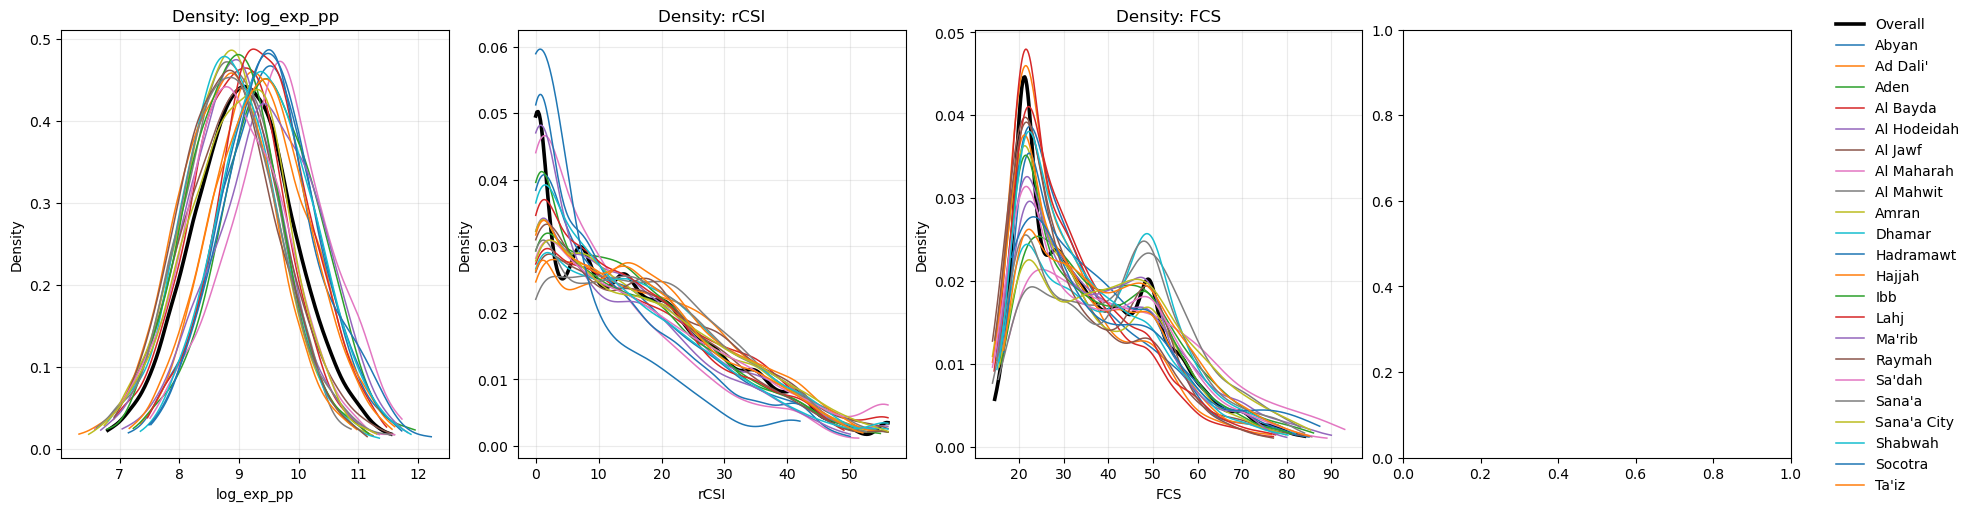

In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cols = ["log_exp_pp", "rCSI", "FCS"]

# Make sure numeric
for c in cols:
    df_keep2[c] = pd.to_numeric(df_keep2[c], errors="coerce")

# Optional: drop extreme outliers to make plots readable (comment out if you don't want)
# for c in cols:
#     lo, hi = df_keep[c].quantile([0.01, 0.99])
#     df_keep.loc[(df_keep[c] < lo) | (df_keep[c] > hi), c] = np.nan

# KDE helper (tries scipy; falls back to density histogram)
def plot_density(ax, data, label, lw=1.2, color=None):
    data = np.asarray(data)
    data = data[np.isfinite(data)]
    if data.size < 5:
        return

    try:
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(data)

        # x grid based on data range (robust to outliers)
        lo, hi = np.quantile(data, [0.01, 0.99])
        if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
            lo, hi = data.min(), data.max()
        x = np.linspace(lo, hi, 300)
        y = kde(x)
        ax.plot(x, y, label=label, linewidth=lw, color=color)
    except Exception:
        ax.hist(
            data, bins=40, density=True, histtype="step",
            linewidth=lw, label=label, color=color
        )

fig, axes = plt.subplots(1, 4, figsize=(18, 5), constrained_layout=True)

for ax, col in zip(axes, cols):
    # Overall in black
    overall = df_keep[col].dropna().values
    plot_density(ax, overall, "Overall", lw=2.6, color="black")

    # ADM1 overlays (auto-colors)
    for adm1, sub in df_keep.groupby("adm1name", dropna=False):
        vals = sub[col].dropna().values
        plot_density(ax, vals, str(adm1), lw=1.1)

    ax.set_title(f"Density: {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.grid(True, alpha=0.25)

# Put one legend for the whole figure (outside)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)

plt.show()

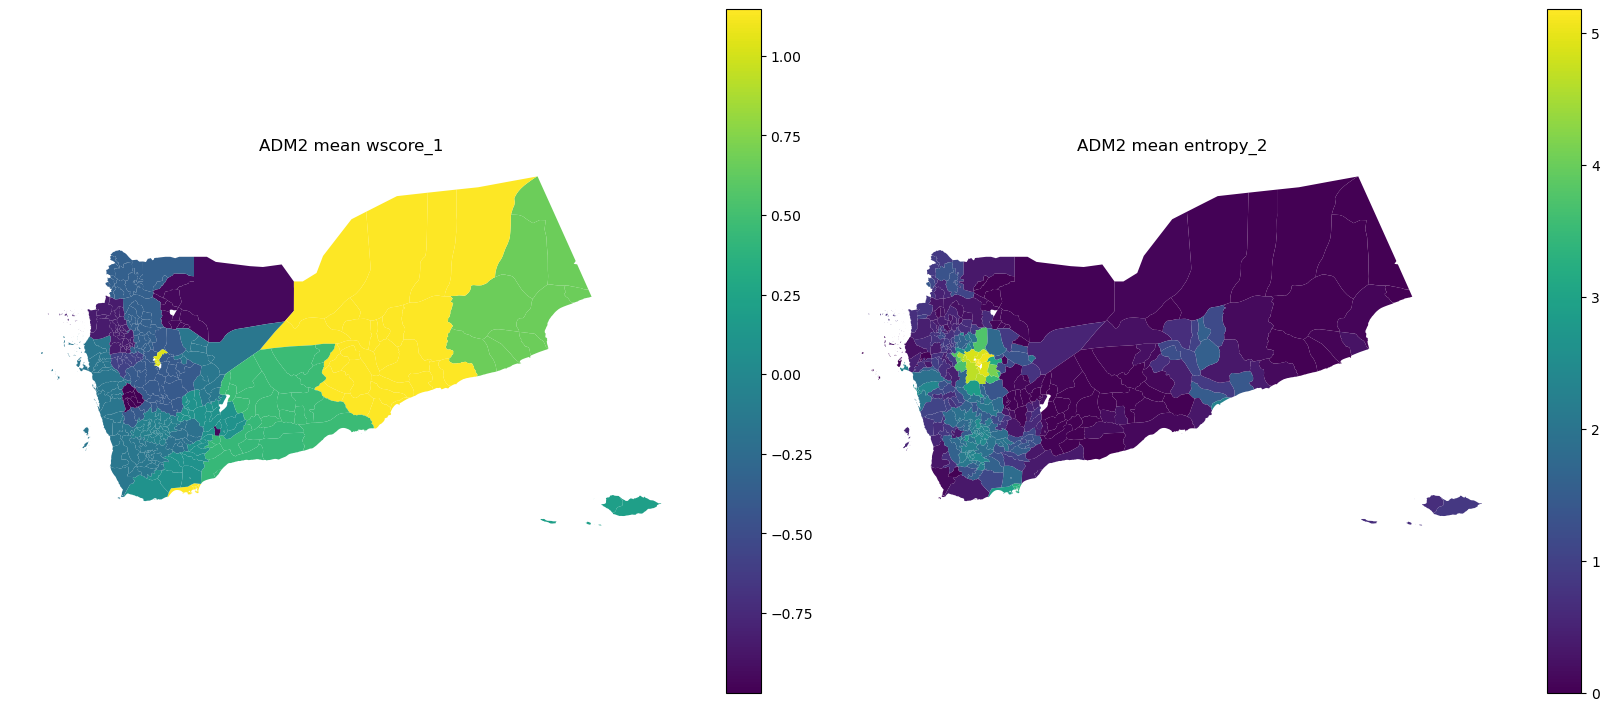

In [41]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Ensure it's a GeoDataFrame
gdf = gpd.GeoDataFrame(df_keep, geometry="geometry")

# 1) Aggregate to ADM2 polygons (mean values per ADM2)
adm2_map = (
    gdf.groupby(["ADM1_NAME", "ADM2_NAME", "ADM2_CODE"], dropna=False)
       .agg(
           wscore_1=("wscore_1", "mean"),
           entropy_2=("entropy_2", "mean"),
           geometry=("geometry", "first")  # same polygon repeated; keep one
       )
       .reset_index()
)

adm2_map = gpd.GeoDataFrame(adm2_map, geometry="geometry", crs=gdf.crs)

# (Optional) reproject for nicer display (Web Mercator)
try:
    adm2_map_3857 = adm2_map.to_crs(3857)
except Exception:
    adm2_map_3857 = adm2_map  # if CRS missing or reprojection fails

# 2) Plot side-by-side choropleths with increasing colormap
fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

adm2_map_3857.plot(
    column="wscore_1",
    ax=axes[0],
    cmap="viridis",          # increasing colormap
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "Missing"},
    linewidth=0.2
)
axes[0].set_title("ADM2 mean wscore_1")
axes[0].axis("off")

adm2_map_3857.plot(
    column="entropy_2",
    ax=axes[1],
    cmap="viridis",          # increasing colormap
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "Missing"},
    linewidth=0.2
)
axes[1].set_title("ADM2 mean entropy_2")
axes[1].axis("off")

plt.show()